In [ ]:
# Introduction to the JupyterLab and Jupyter Notebooks


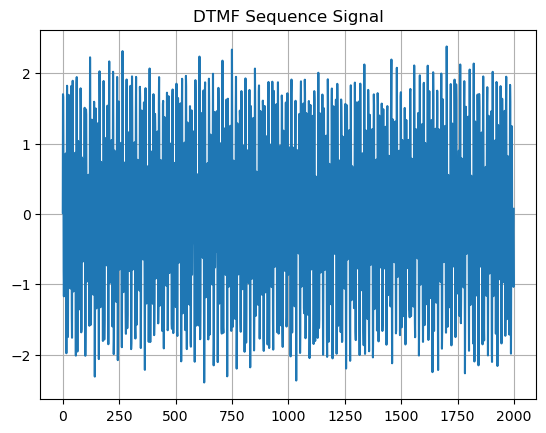

Detected Number: 08242474040


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Sampling frequency
fs = 8000  

# DTMF frequency groups
low_freqs = [697, 770, 852, 941]
high_freqs = [1209, 1336, 1477]

# Mapping dictionary
dtmf_map = {
    (697,1209): '1', (697,1336): '2', (697,1477): '3',
    (770,1209): '4', (770,1336): '5', (770,1477): '6',
    (852,1209): '7', (852,1336): '8', (852,1477): '9',
    (941,1336): '0'
}
            

def goertzel(signal, target_freq, fs):
    N = len(signal)
    k = int(0.5 + (N * target_freq) / fs)
    omega = (2 * np.pi * k) / N
    coeff = 2 * np.cos(omega)

    s_prev = 0
    s_prev2 = 0

    for sample in signal:
        s = sample + coeff * s_prev - s_prev2
        s_prev2 = s_prev
        s_prev = s

    power = s_prev2**2 + s_prev**2 - coeff * s_prev * s_prev2
    return power
def detect_dtmf(signal):
    low_powers = []
    high_powers = []

    for f in low_freqs:
        low_powers.append(goertzel(signal, f, fs))

    for f in high_freqs:
        high_powers.append(goertzel(signal, f, fs))

    # Get max values
    max_low = max(low_powers)
    max_high = max(high_powers)

    # Threshold (you can tune this)
    threshold = 100

    if max_low < threshold or max_high < threshold:
        return None, None

    low_freq = low_freqs[np.argmax(low_powers)]
    high_freq = high_freqs[np.argmax(high_powers)]

    return low_freq, high_freq

digits = "08242474040"
duration = 0.3
silence = 0.05

signal = np.array([])

for d in digits:
    for (low, high), val in dtmf_map.items():
        if val == d:
            t = np.arange(0, duration, 1/fs)
            tone = np.sin(2*np.pi*low*t) + np.sin(2*np.pi*high*t)
            
            gap = np.zeros(int(fs * silence))
            signal = np.concatenate((signal, tone, gap))

# Add noise
noise = 0.2 * np.random.randn(len(signal))
signal = signal + noise
plt.plot(signal[:2000])
plt.title("DTMF Sequence Signal")
plt.grid()
plt.show()     

frame_size = int(fs * duration)
step = int(fs * (duration + silence))

detected_digits = []

for i in range(0, len(signal), step):
    frame = signal[i:i+frame_size]

    if len(frame) < frame_size:
        continue

    low, high = detect_dtmf(frame)

    if low is None:
        continue

    digit = dtmf_map.get((low, high), '?')
    detected_digits.append(digit)

print("Detected Number:", "".join(detected_digits))